<a href="https://colab.research.google.com/github/adityasujithk-creator/PRODS/blob/main/Finance_Project_Data_Analysis_of_Stock_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finance Data Project

In this data project we will focus on exploratory data analysis of stock prices. Keep in mind, this project is just meant to practice your visualization and pandas skills, it is not meant to be a robust financial analysis or be taken as financial advice.

NOTE: This project is extremely challenging because it will introduce a lot of new concepts and have you looking things up on your own (we'll point you in the right direction) to try to solve the tasks issued. Feel free to just go through the solutions lecture notebook and video as a "walkthrough" project if you don't want to have to look things up yourself. You'll still learn a lot that way!

We'll focus on bank stocks and see how they progressed throughout the financial crisis all the way to early 2016.

Data:
We need to get data using pandas datareader. We will get stock information for the following banks:

* Bank of America
*   CitiGroup
*   Goldman Sachs
*   JPMorgan Chase
*   Morgan Stanley
*   Wells Fargo

Figure out how to get the stock data from Jan 1st 2006 to Jan 1st 2016 for each of these banks. Set each bank to be a separate dataframe, with the variable name for that bank being its ticker symbol. This will involve a few steps:

Use datetime to set start and end datetime

1.   Use datetime to set start and end datetime
objects
2.   Figure out the ticker symbol for each bank.
2.   Figure out how to use datareader to grab info on the stock.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_pickle('all_banks')

In [3]:
!pip install pandas-datareader

In [4]:
!pip install yfinance

In [5]:
import yfinance as yf
from datetime import datetime

In [6]:
start = datetime(2006, 1, 1)
end = datetime(2016, 1, 1)

In [7]:
BAC = yf.download("BAC", start=start, end=end)
C = yf.download("C", start=start, end=end)
GS = yf.download("GS", start=start, end=end)
JPM = yf.download("JPM", start=start, end=end)
MS = yf.download("MS", start=start, end=end)
WFC = yf.download("WFC", start=start, end=end)

/tmp/ipykernel_30691/2562495301.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  BAC = yf.download("BAC", start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_30691/2562495301.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  C = yf.download("C", start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_30691/2562495301.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  GS = yf.download("GS", start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_30691/2562495301.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  JPM = yf.download("JPM", start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_30691/2562495301.py:5: FutureWarning: YF.download() has

In [8]:
BAC

Price,Close,High,Low,Open,Volume
Ticker,BAC,BAC,BAC,BAC,BAC
Date,,,,,
2006-01-03,30.487928,30.552685,29.885682,30.384314,16296700
2006-01-04,30.164139,30.591540,30.079953,30.436120,17757900
2006-01-05,30.202999,30.326040,29.995775,30.164146,14970700
2006-01-06,30.157667,30.377843,30.015199,30.306610,12599800
2006-01-09,30.177097,30.416703,30.021680,30.254808,15619400
...,...,...,...,...,...
2015-12-24,13.793180,13.881034,13.753246,13.833114,29369400
2015-12-28,13.681363,13.761231,13.561562,13.753244,41777500


In [9]:
tickers = ['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']

In [10]:
bank_stocks = pd.concat([BAC, C, GS, JPM, MS, WFC], axis=1, keys=tickers)

In [11]:
bank_stocks.columns = bank_stocks.columns.droplevel(2)

bank_stocks.columns.names = ['Bank Ticker', 'Stock Info']

In [12]:
bank_stocks.head()

Bank Ticker        BAC                                                      C  \
Stock Info       Close       High        Low       Open    Volume       Close   
Date                                                                            
2006-01-03   30.487928  30.552685  29.885682  30.384314  16296700  314.316772   
2006-01-04   30.164139  30.591540  30.079953  30.436120  17757900  308.513763   
2006-01-05   30.202999  30.326040  29.995775  30.164146  14970700  310.044189   
2006-01-06   30.157667  30.377843  30.015199  30.306610  12599800  310.044189   
2006-01-09   30.177097  30.416703  30.021680  30.254808  15619400  308.577576   

Bank Ticker                                               ...         MS  \
Stock Info         High         Low        Open   Volume  ...      Close   
Date                                                      ...              
2006-01-03   314.890688  306.792053  312.467479  1537600  ...  31.182053   
2006-01-04   313.105130  308.322465  311.574681  1870960  ...  31.203449   
2006-01-05   311.064476  308.641267  308.896338  1143160  ...  31.289013   
2006-01-06   311.829710  307.365890  311.702164  1370210  ...  31.321079   
2006-01-09   310.809486  308.003660  309.916726  1680740  ...  31.652641   

Bank Ticker                                                  WFC             \
Stock Info        High        Low       Open   Volume      Close       High   
Date                                                                          
2006-01-03   31.278310  30.342474  30.572421  5377000  18.274664  18.317630   
2006-01-04   31.700779  31.203449  31.390618  7977800  18.062706  18.228839   
2006-01-05   31.331795  31.026980  31.310404  5778000  18.042652  18.077024   
2006-01-06   31.470812  31.043002  31.428032  6889800  18.148630  18.203053   
2006-01-09   31.706119  31.347826  31.353175  4144500  18.145765  18.231697   

Bank Ticker                                  
Stock Info         Low       Open    Volume  
Date                                         
2006-01-03   17.870788  18.102802  11016400  
2006-01-04   17.968181  18.217381  10870000  
2006-01-05   17.936670  18.045516  10158000  
2006-01-06   17.979632  18.091343   8403800  
2006-01-09   18.077021  18.145765   5619600  

[5 rows x 30 columns]

Max close Price of each bank's stock throughot the time period

In [13]:
bank_stocks.xs(key='Close', axis=1, level='Stock Info').max()

,0
Bank Ticker,
BAC,36.870277
C,374.732635
GS,181.499527
JPM,52.581123
MS,48.881321
WFC,43.081268


In [14]:
# Or
for tick in tickers:
    print(tick, bank_stocks[tick]['Close'].max())

BAC 36.870277404785156
C 374.7326354980469
GS 181.49952697753906
JPM 52.58112335205078
MS 48.88132095336914
WFC 43.081268310546875


A new DF called returns. It containd the return of each bank's stock

In [15]:
returns = pd.DataFrame()

In [16]:
for tick in tickers:
    returns[tick + ' Return'] = bank_stocks[tick]['Close'].pct_change()

In [17]:
returns.head()

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013812,-0.005771,0.000686,-0.011598
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001110
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005874
2006-01-09,0.000644,-0.004730,0.012030,0.016242,0.010586,-0.000158


A pairplot

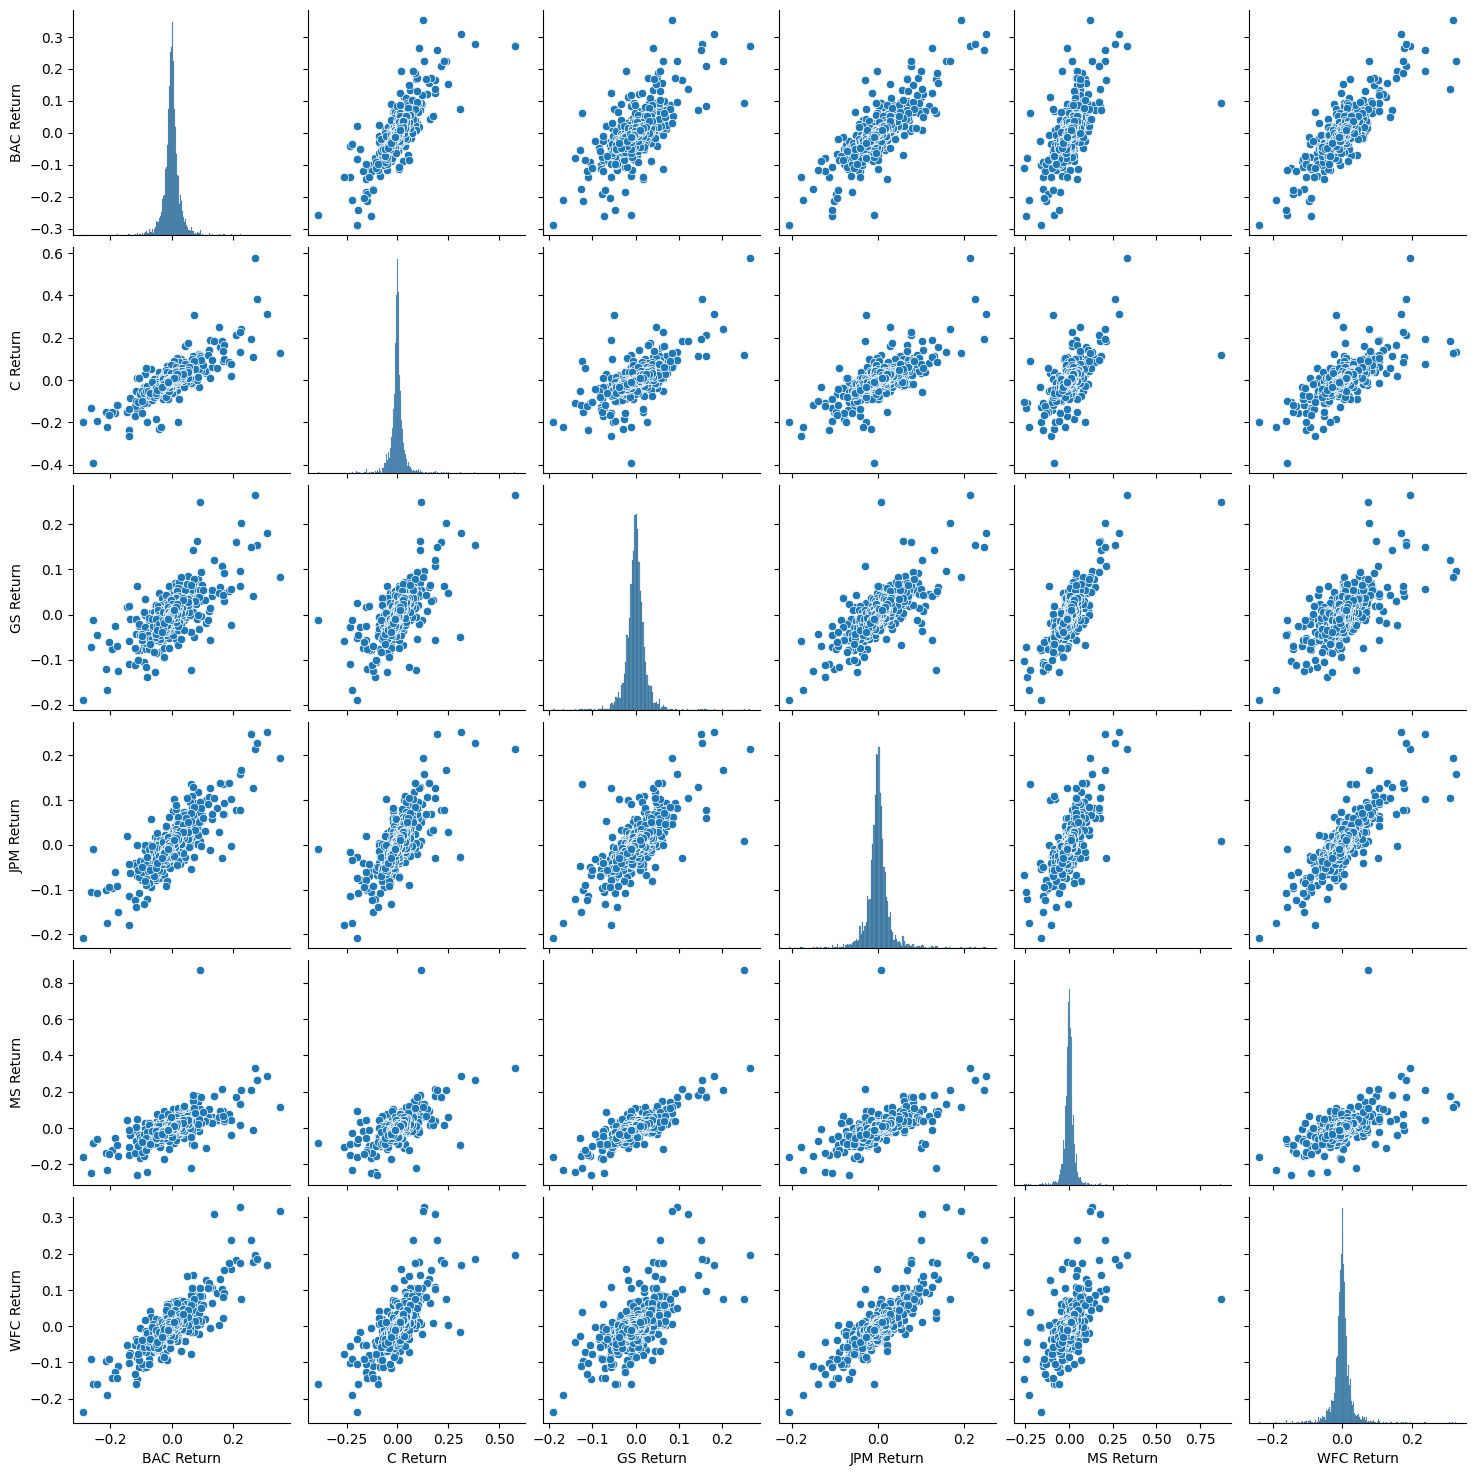

In [18]:
sns.pairplot(returns[1:])

Best and Worst single day returns

In [19]:
returns.min()

,0
BAC Return,-0.289694
C Return,-0.390244
GS Return,-0.189596
JPM Return,-0.207274
MS Return,-0.258929
WFC Return,-0.238223


In [20]:
returns.idxmin()

,0
BAC Return,2009-01-20
C Return,2009-02-27
GS Return,2009-01-20
JPM Return,2009-01-20
MS Return,2008-10-09
WFC Return,2009-01-20


In [21]:
returns.max()

,0
BAC Return,0.352692
C Return,0.578249
GS Return,0.264678
JPM Return,0.250967
MS Return,0.869834
WFC Return,0.327645


In [22]:
returns.idxmax()

,0
BAC Return,2009-04-09
C Return,2008-11-24
GS Return,2008-11-24
JPM Return,2009-01-21
MS Return,2008-10-13
WFC Return,2008-07-16


Riskiest Year based on Standard Deviation

In [23]:
returns.std()

,0
BAC Return,0.036659
C Return,0.038672
GS Return,0.025386
JPM Return,0.027675
MS Return,0.037717
WFC Return,0.030195


In [24]:
returns.loc['2015-01-01':'2015-12-31'].std()

,0
BAC Return,0.016174
C Return,0.015288
GS Return,0.014043
JPM Return,0.014006
MS Return,0.016287
WFC Return,0.012552


Create a distplot of 2015 returns on Morgan Stanley



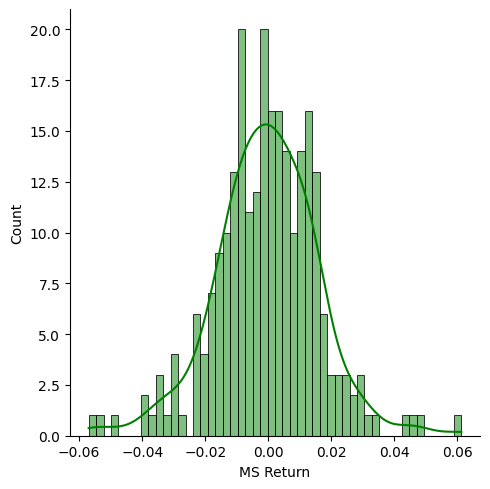

In [25]:
sns.displot(returns.loc['2015-01-01':'2015-12-31']['MS Return'],bins=50, kde = True, color='green')

Create a distplot of 2008 returns on Citi Group

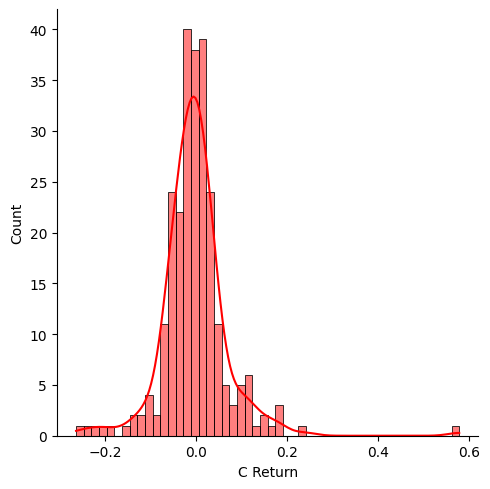

In [26]:
sns.displot(returns.loc['2008-01-01':'2008-12-31']['C Return'],bins=50, kde = True, color='red')

A line plot showing Close Price for each bank for the entire index of time

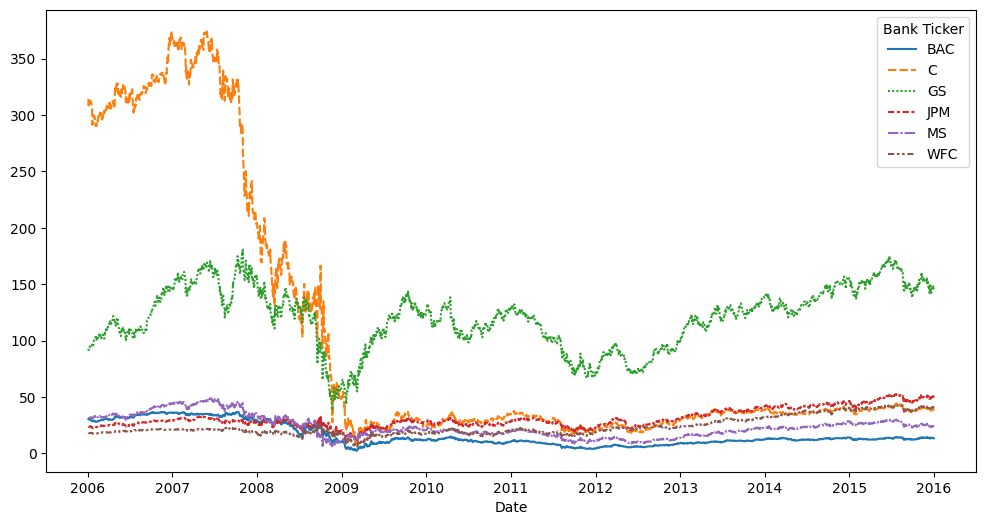

In [27]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=bank_stocks.xs('Close', axis=1, level='Stock Info'))
plt.show()

<Axes: xlabel='Date'>

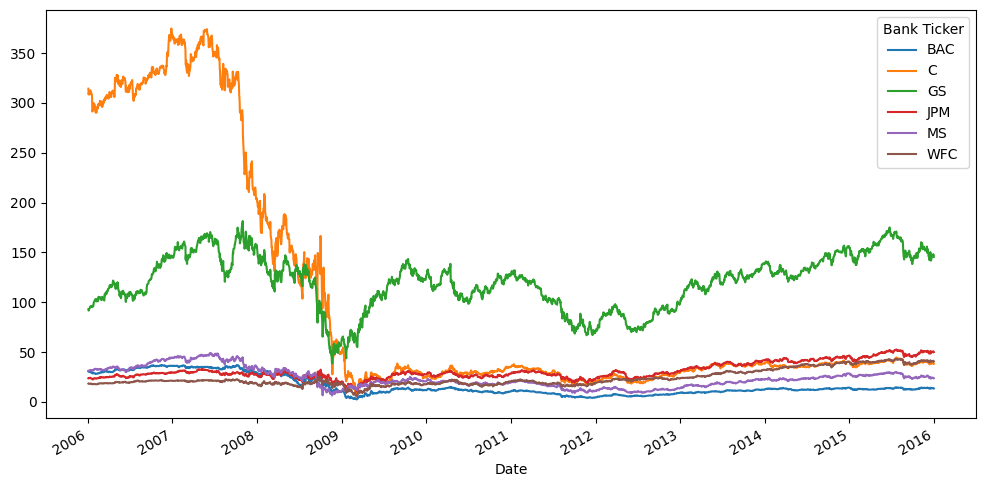

In [28]:
# Or
bank_stocks.xs('Close', axis=1, level='Stock Info').plot(figsize=(12, 6))

In [29]:
close_df = bank_stocks.xs('Close', axis=1, level='Stock Info')

print(close_df.shape)
close_df.head()

(2517, 6)


Bank Ticker,BAC,C,GS,JPM,MS,WFC
Date,,,,,,
2006-01-03,30.487928,314.316772,92.949333,23.633678,31.182053,18.274664
2006-01-04,30.164139,308.513763,91.665474,23.497282,31.203449,18.062706
2006-01-05,30.202999,310.044189,91.629433,23.568449,31.289013,18.042652
2006-01-06,30.157667,310.044189,92.927750,23.734503,31.321079,18.148630
2006-01-09,30.177097,308.577576,94.045677,24.119993,31.652641,18.145765


In [30]:
!pip install plotly -q

import plotly.express as px
import plotly.io as pio

pio.renderers.default = "colab"

close_df = bank_stocks.xs('Close', axis=1, level='Stock Info')

fig = px.line(close_df, title="Closing Prices of Bank Stocks")
fig.show()